In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid")

DATA_PATH = Path("/Users/ilyaklimasin/ecommerce_product_analytics/data")
list(DATA_PATH.glob("*.csv"))

[PosixPath('/Users/ilyaklimasin/ecommerce_product_analytics/data/olist_sellers_dataset.csv'),
 PosixPath('/Users/ilyaklimasin/ecommerce_product_analytics/data/product_category_name_translation.csv'),
 PosixPath('/Users/ilyaklimasin/ecommerce_product_analytics/data/olist_orders_dataset.csv'),
 PosixPath('/Users/ilyaklimasin/ecommerce_product_analytics/data/olist_order_items_dataset.csv'),
 PosixPath('/Users/ilyaklimasin/ecommerce_product_analytics/data/olist_customers_dataset.csv'),
 PosixPath('/Users/ilyaklimasin/ecommerce_product_analytics/data/olist_geolocation_dataset.csv'),
 PosixPath('/Users/ilyaklimasin/ecommerce_product_analytics/data/olist_order_payments_dataset.csv'),
 PosixPath('/Users/ilyaklimasin/ecommerce_product_analytics/data/olist_order_reviews_dataset.csv'),
 PosixPath('/Users/ilyaklimasin/ecommerce_product_analytics/data/olist_products_dataset.csv')]

In [45]:
customers = pd.read_csv(DATA_PATH / "olist_customers_dataset.csv")
orders = pd.read_csv(DATA_PATH / "olist_orders_dataset.csv")
order_items = pd.read_csv(DATA_PATH / "olist_order_items_dataset.csv")
payments = pd.read_csv(DATA_PATH / "olist_order_payments_dataset.csv")
reviews = pd.read_csv(DATA_PATH / "olist_order_reviews_dataset.csv")
products = pd.read_csv(DATA_PATH / "olist_products_dataset.csv")
sellers = pd.read_csv(DATA_PATH / "olist_sellers_dataset.csv")
geolocation = pd.read_csv(DATA_PATH / "olist_geolocation_dataset.csv")
category_translation = pd.read_csv(
    DATA_PATH / "product_category_name_translation.csv"
)

In [46]:
tables = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "geolocation": geolocation,
    "category_translation": category_translation,
}

table_sizes = []
for table_name, dataframe in tables.items():
    table_sizes.append({
        "table": table_name,
        "rows": dataframe.shape[0],
        "columns": dataframe.shape[1],
    })
table_sizes = pd.DataFrame(table_sizes)
table_sizes.sort_values("rows", ascending=False)

,table,rows,columns
7,geolocation,1000163,5
2,order_items,112650,7
3,payments,103886,5
0,customers,99441,5
1,orders,99441,8
4,reviews,99224,7
5,products,32951,9
6,sellers,3095,4
8,category_translation,71,2


In [47]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [48]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [49]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [50]:
for table_name, dataframe in tables.items():
    print(f"\n{table_name}")
    print(dataframe.columns.tolist())


customers
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

orders
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

order_items
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

payments
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

reviews
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

products
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

sellers
['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

geolocation
['geolocation_zi

In [51]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [52]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for column in date_columns:
    orders[column] = pd.to_datetime(orders[column], errors="coerce")

orders[date_columns].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [53]:
def missing_summary(dataframe):
    missing_count = dataframe.isna().sum()
    missing_share = dataframe.isna().mean()*100
    result = pd.DataFrame({
        "missing_count": missing_count,
        "missing_percent": missing_share,
    })
    return result[result["missing_count"] > 0].sort_values("missing_percent", ascending=False)

missing_summary(orders)

,missing_count,missing_percent
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
order_approved_at,160,0.16


In [54]:
missing_summary(products)


,missing_count,missing_percent
product_category_name,610,1.85
product_name_lenght,610,1.85
product_description_lenght,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01


In [55]:
missing_summary(reviews)

,missing_count,missing_percent
review_comment_title,87656,88.34
review_comment_message,58247,58.70


In [56]:
duplicate_summary = []
for table_name, dataframe in tables.items():
    duplicate_summary.append({
        "table": table_name,
        "full_duplicates": dataframe.duplicated().sum()
    })

pd.DataFrame(duplicate_summary)

,table,full_duplicates
0,customers,0
1,orders,0
2,order_items,0
3,payments,0
4,reviews,0
5,products,0
6,sellers,0
7,geolocation,261831
8,category_translation,0


In [57]:
orders["order_id"].nunique(), len(orders)  

(99441, 99441)

In [58]:
customers["customer_id"].nunique(), len(customers)

(99441, 99441)

In [59]:
order_items["order_id"].value_counts().head()

order_id
8272b63d03f5f79c56e9e4120aec44ef    21
1b15974a0141d54e36626dca3fdc731a    20
ab14fdcfbe524636d65ee38360e22ce8    20
9ef13efd6949e4573a18964dd1bbe7f5    15
428a2f660dc84138d969ccd69a0ab6d5    15
Name: count, dtype: int64

In [60]:
payments["order_id"].value_counts().head()

order_id
fa65dad1b0e818e3ccc5cb0e39231352    29
ccf804e764ed5650cd8759557269dc13    26
285c2e15bebd4ac83635ccc563dc71f4    22
895ab968e7bb0d5659d16cd74cd1650c    21
fedcd9f7ccdc8cba3a18defedd1a5547    19
Name: count, dtype: int64

In [61]:
order_status = (
    orders["order_status"]
    .value_counts(dropna=False)
    .reset_index()
)

order_status.columns = [
    "order_status",
    "orders_count"
]

order_status

,order_status,orders_count
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


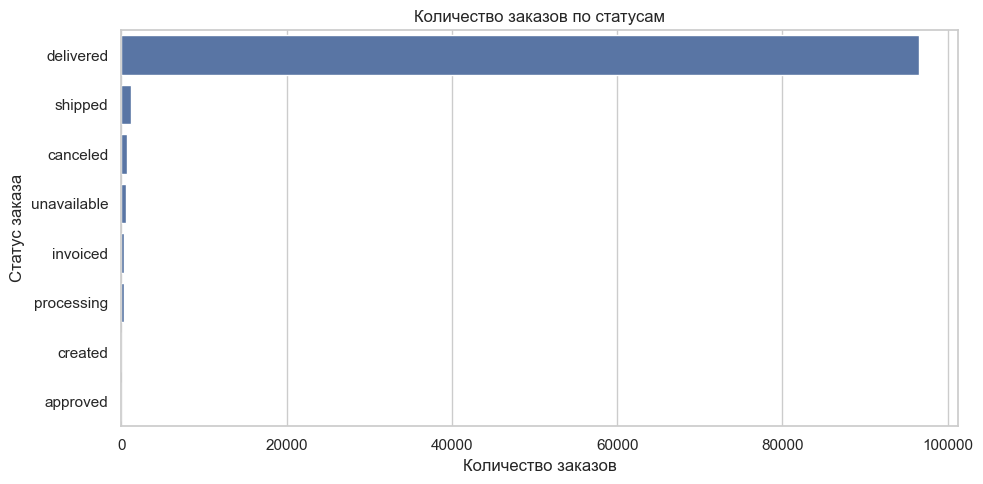

In [62]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=order_status,
    x="orders_count",
    y="order_status"
)

plt.title("Количество заказов по статусам")
plt.xlabel("Количество заказов")
plt.ylabel("Статус заказа")
plt.tight_layout()
plt.show()

In [63]:
print("Start of period: ", orders["order_purchase_timestamp"].min())
print("End of period: ", orders["order_purchase_timestamp"].max())

Start of period:  2016-09-04 21:15:19
End of period:  2018-10-17 17:30:18


In [64]:
delivered_orders = orders[orders["order_delivered_customer_date"].notna()].copy()
invalid_delivery_dates = delivered_orders[delivered_orders["order_delivered_customer_date"] < delivered_orders["order_purchase_timestamp"]]
len(invalid_delivery_dates)

0

In [65]:
delivered_orders["is_late"] = (delivered_orders["order_delivered_customer_date"] > delivered_orders["order_estimated_delivery_date"])
delivered_orders["is_late"].value_counts(normalize=True)

is_late
False   0.92
True    0.08
Name: proportion, dtype: float64

## Выводы первого этапа

1. Загружены и изучены 9 связанных таблиц Olist, содержащих информацию о заказах, клиентах, товарах, продавцах, платежах, отзывах и географии.

2. Данные охватывают период с 4 сентября 2016 года по 17 октября 2018 года.

3. Таблица `orders` содержит 99 441 заказ. Поле `order_id` является её уникальным ключом: количество уникальных идентификаторов совпадает с количеством строк.

4. Поле `customer_id` также уникально внутри таблицы `customers`. При этом один заказ может встречаться несколько раз в таблицах `order_items`, `payments` и `reviews`, поскольку заказ может содержать несколько товаров, платежей или записей с отзывами.

5. В таблице `orders` обнаружены пропуски:
   - `order_delivered_customer_date` — 2 965 значений, около 2,98%;
   - `order_delivered_carrier_date` — 1 783 значения, около 1,79%;
   - `order_approved_at` — 160 значений, около 0,16%.

6. В таблице `products` у 610 товаров отсутствуют категория и текстовые характеристики, а у 2 товаров отсутствуют сведения о весе и размерах.

7. В таблице `reviews` текстовые поля часто не заполнены: отсутствуют 87 656 заголовков и 58 247 текстов отзывов. Это не обязательно является ошибкой, поскольку клиент мог оставить только числовую оценку.

8. Полные дубликаты отсутствуют во всех основных бизнес-таблицах. В таблице `geolocation` найдено 261 831 полных повторов, однако их не следует удалять без дополнительного исследования структуры географических данных.

9. Большинство заказов имеет статус `delivered`: 96 478 заказов, или около 97,02%. Остальные заказы находятся в статусах `shipped`, `canceled`, `unavailable`, `invoiced`, `processing`, `created` и `approved`.

10. Среди заказов с указанной фактической датой доставки не найдено случаев, когда доставка произошла раньше оформления заказа.

11. Часть пропусков в датах доставки связана со статусами заказов: отменённые, недоступные или ещё не завершённые заказы могли не быть переданы перевозчику или доставлены клиенту.

12. Столбцы с датами преобразованы в формат `datetime`, что позволит рассчитывать сроки доставки, динамику заказов и когортные показатели.

13. На следующем этапе таблицы будут объединены с учётом их уровня детализации для расчёта выручки, среднего чека, количества заказов и показателей доставки.